In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


Load dataset

In [2]:
df = pd.read_csv("breast-cancer-selected-columns.csv")

Check the dataset

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430


In [4]:
df.shape

(569, 10)

In [5]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean'],
      dtype='object')

In [6]:
df.dtypes

id                       int64
diagnosis               object
radius_mean            float64
texture_mean           float64
perimeter_mean         float64
area_mean              float64
smoothness_mean        float64
compactness_mean       float64
concavity_mean         float64
concave points_mean    float64
dtype: object

In [7]:
df.isnull().sum()

id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64

In [8]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
df = df.drop(columns = ["id"])

In [10]:
x = df.drop(columns = ["diagnosis"])
y = df["diagnosis"]

In [11]:
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430


In [12]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

Now Convert B and M into numbers using labelencoder

In [13]:
le = LabelEncoder()
y = le.fit_transform(df["diagnosis"])

In [14]:
y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [15]:
le.classes_

array(['B', 'M'], dtype=object)

In [16]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430


Split training and testing data 

In [17]:
x_train , x_test, y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [18]:
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train shape : ",y_train.shape)
print("y_test shape : ",y_test.shape)

x_train shape :  (455, 8)
x_test shape :  (114, 8)
y_train shape :  (455,)
y_test shape :  (114,)


Feature Scalling 

In [19]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Create KNN model


In [20]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

Train KNN


In [21]:
knn.fit(x_train_scaled,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
y_pred = knn.predict(x_test_scaled)

In [23]:
y_pred[:10]

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0])

In [24]:
y_test[:10]

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0])

In [25]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy_score:", accuracy)

Accuracy_score: 0.9385964912280702


In [26]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[67  4]
 [ 3 40]]


In [27]:
print(classification_report(y_test,y_pred,target_names = ["Benign","Malignant"]))

              precision    recall  f1-score   support

      Benign       0.96      0.94      0.95        71
   Malignant       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



Now Test Different K Values


In [29]:
k_values = range(1, 21)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(x_train_scaled, y_train)
    
    y_pred_k = knn.predict(x_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred_k)
    
    accuracies.append(accuracy)

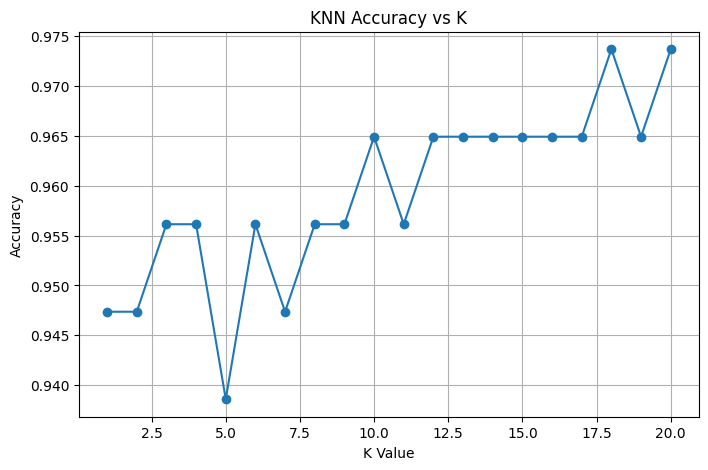

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

plt.grid()
plt.show()

In [31]:
best_k = k_values[np.argmax(accuracies)]

print("Best K:", best_k)

Best K: 18


In [32]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

In [33]:
final_knn.fit(x_train_scaled, y_train)

,n_neighbors,18
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
final_pred = final_knn.predict(x_test_scaled)

In [35]:
final_accuracy = accuracy_score(y_test, final_pred)

print("Final Accuracy:", final_accuracy)

Final Accuracy: 0.9736842105263158


In [36]:
cm = confusion_matrix(y_test, final_pred)

print(cm)

[[70  1]
 [ 2 41]]


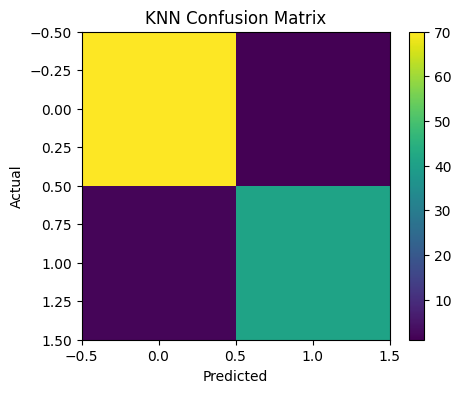

In [37]:
plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()

In [38]:
print(classification_report(
    y_test,
    final_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        71
   Malignant       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

